# Fine-grid local search for truth-free filtered-LCB

This notebook performs a **fine-grid post-processing sweep** around the current best rule:

- current best: `filtered_lcb_proxy__lam_0.500__tau_0.020`
- goal: reduce the remaining undercovered test points while preserving pointwise stability

It does **not** retrain SVGP and does **not** rerun the original formal experiment.

## Main ideas

1. Load the original formal cross-fit outputs from the saved `rep000 ... rep099` folders.
2. Recompute truth-free reselection locally for a finer grid:
   - lambda grid near 0.5
   - tau grid near 0.02
3. Rank candidates by **pointwise-first** criteria:
   - undercovered point count
   - minimum pointwise coverage
   - 10th percentile pointwise coverage
   - direction instability
4. Inspect the remaining worst points for the top candidate.

Selection remains truth-free:
- no use of `true_f` in selection
- no use of final hit in selection

If `true_f` is present in the saved deploy files, it is used only for offline evaluation after selection.


In [1]:
from __future__ import annotations

import math
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 160

try:
    from scipy.stats import t as student_t
except Exception:
    student_t = None


## 1. User settings

In [2]:
# Original formal outputs
FORMAL_ROOT = Path(r"C:\Users\yangy\26 spring\with reference\more_cross")

# Previous filtered-LCB outputs, used only for comparison / reference if needed
PREV_LCB_ROOT = Path(r"C:\Users\yangy\26 spring\with reference\lcb")

OUT_DIR = PREV_LCB_ROOT / "fine_grid_search_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Fine-grid around the currently best region
LAMBDA_GRID = [0.25, 0.50, 0.75, 1.00]
TAU_GRID = [0.01, 0.02, 0.03]

NOMINAL = 0.95
LCB_DELTA = 0.05
FALLBACK = "closest"

print("FORMAL_ROOT =", FORMAL_ROOT)
print("PREV_LCB_ROOT =", PREV_LCB_ROOT)
print("OUT_DIR =", OUT_DIR)
print("LAMBDA_GRID =", LAMBDA_GRID)
print("TAU_GRID =", TAU_GRID)


FORMAL_ROOT = C:\Users\yangy\26 spring\with reference\more_cross
PREV_LCB_ROOT = C:\Users\yangy\26 spring\with reference\lcb
OUT_DIR = C:\Users\yangy\26 spring\with reference\lcb\fine_grid_search_outputs
LAMBDA_GRID = [0.25, 0.5, 0.75, 1.0]
TAU_GRID = [0.01, 0.02, 0.03]


## 2. Load original formal rep folders

In [3]:
REP_RE = re.compile(r"rep(\d+)")

@dataclass
class RepData:
    rep_id: int
    rep_dir: Path
    x: np.ndarray
    alphas: np.ndarray
    deploy_mu: np.ndarray
    deploy_std: np.ndarray
    deploy_lower: np.ndarray
    deploy_upper: np.ndarray
    calib_mu: np.ndarray
    calib_std: np.ndarray
    calib_lower: np.ndarray
    calib_upper: np.ndarray
    pseudo_truth: np.ndarray
    calib_indicators: np.ndarray
    directional_cov: np.ndarray
    baseline_alpha_star: np.ndarray
    deploy_final_df: Optional[pd.DataFrame] = None


def parse_rep_id(path: Path) -> int:
    m = REP_RE.search(path.name)
    if m is None:
        raise ValueError(f"Cannot parse rep id from {path}")
    return int(m.group(1))


def find_single(rep_dir: Path, pattern: str, required: bool = True) -> Optional[Path]:
    matches = list(rep_dir.glob(pattern))
    if len(matches) == 1:
        return matches[0]
    if len(matches) == 0 and not required:
        return None
    raise FileNotFoundError(f"Expected exactly one match for {pattern} in {rep_dir}, got {len(matches)}")


def load_rep(rep_dir: Path) -> RepData:
    rep_id = parse_rep_id(rep_dir)

    deploy_bank_path = find_single(rep_dir, "deploy_full_by_alpha_rep*_A*_J*.npz")
    calib_bank_path = find_single(rep_dir, "calib_crossfit_interval_bank_rep*_S*_A*_B*_J*.npz")
    directional_cov_path = find_single(rep_dir, "directional_coverage_rep*_S*_A*_J*.npy")
    alpha_star_path = find_single(rep_dir, "alpha_star_curve_rep*.csv")
    deploy_final_path = find_single(rep_dir, "deploy_final_rep*_J*.csv", required=False)

    deploy_bank = np.load(deploy_bank_path)
    calib_bank = np.load(calib_bank_path)

    x = np.array(deploy_bank["x"], dtype=float)
    alphas = np.array(deploy_bank["alphas"], dtype=float)
    deploy_mu = np.array(deploy_bank["mu"], dtype=float)
    deploy_std = np.array(deploy_bank["std"], dtype=float)
    deploy_lower = np.array(deploy_bank["lower"], dtype=float)
    deploy_upper = np.array(deploy_bank["upper"], dtype=float)

    calib_mu = np.array(calib_bank["mu"], dtype=float)
    calib_std = np.array(calib_bank["std"], dtype=float)
    calib_lower = np.array(calib_bank["lower"], dtype=float)
    calib_upper = np.array(calib_bank["upper"], dtype=float)
    pseudo_truth = np.array(calib_bank["pseudo_truth"], dtype=float)
    calib_indicators = np.array(calib_bank["indicators"], dtype=float)

    directional_cov = np.array(np.load(directional_cov_path), dtype=float)
    alpha_df = pd.read_csv(alpha_star_path).sort_values("x").reset_index(drop=True)
    baseline_alpha_star = alpha_df["alpha_star"].to_numpy(dtype=float)

    if not np.allclose(alpha_df["x"].to_numpy(dtype=float), x):
        raise ValueError(f"x mismatch in alpha_star_curve for rep {rep_id}")
    if directional_cov.shape != pseudo_truth.shape:
        raise ValueError(f"directional_cov shape mismatch in rep {rep_id}")

    deploy_final_df = None
    if deploy_final_path is not None:
        deploy_final_df = pd.read_csv(deploy_final_path).sort_values("x").reset_index(drop=True)
        if not np.allclose(deploy_final_df["x"].to_numpy(dtype=float), x):
            raise ValueError(f"x mismatch in deploy_final for rep {rep_id}")

    return RepData(
        rep_id=rep_id,
        rep_dir=rep_dir,
        x=x,
        alphas=alphas,
        deploy_mu=deploy_mu,
        deploy_std=deploy_std,
        deploy_lower=deploy_lower,
        deploy_upper=deploy_upper,
        calib_mu=calib_mu,
        calib_std=calib_std,
        calib_lower=calib_lower,
        calib_upper=calib_upper,
        pseudo_truth=pseudo_truth,
        calib_indicators=calib_indicators,
        directional_cov=directional_cov,
        baseline_alpha_star=baseline_alpha_star,
        deploy_final_df=deploy_final_df,
    )


def discover_reps(root: Path) -> List[RepData]:
    rep_dirs = sorted([p for p in root.iterdir() if p.is_dir() and REP_RE.search(p.name)], key=parse_rep_id)
    if not rep_dirs:
        raise FileNotFoundError(f"No repXXX directories found in {root}")
    reps = [load_rep(p) for p in rep_dirs]
    x0 = reps[0].x
    a0 = reps[0].alphas
    for rep in reps[1:]:
        if not np.allclose(rep.x, x0):
            raise ValueError(f"x-grid mismatch at rep {rep.rep_id}")
        if not np.allclose(rep.alphas, a0):
            raise ValueError(f"alpha-grid mismatch at rep {rep.rep_id}")
    return reps

reps = discover_reps(FORMAL_ROOT)
print(f"Loaded {len(reps)} replications")
print("J =", len(reps[0].x))
print("alpha grid =", reps[0].alphas)


Loaded 100 replications
J = 50
alpha grid = [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


## 3. Truth-free objects and selection rule

In [4]:
def t_critical_one_sided(df: int, level: float) -> float:
    if student_t is not None:
        return float(student_t.ppf(level, df))
    return 1.833


def compute_truthfree_objects(rep: RepData, eps: float = 1e-12) -> Dict[str, np.ndarray]:
    # calib_indicators shape = [S, A, B, J]
    S, A, B, J = rep.calib_indicators.shape

    calib_cov_dir = rep.calib_indicators.mean(axis=2)   # [S, A, J]
    calib_cov_cf = calib_cov_dir.mean(axis=0)           # [A, J]

    dep_hit_pseudo = (
        (rep.pseudo_truth >= rep.deploy_lower[None, :, :]) &
        (rep.pseudo_truth <= rep.deploy_upper[None, :, :])
    ).astype(float)                                     # [S, A, J]
    dep_cov_pseudo = dep_hit_pseudo.mean(axis=0)        # [A, J]
    g_pseudo = dep_cov_pseudo - calib_cov_cf            # [A, J]

    dir_sd = np.std(calib_cov_dir, axis=0, ddof=1 if calib_cov_dir.shape[0] > 1 else 0)
    calib_width_mean = (rep.calib_upper - rep.calib_lower).mean(axis=(0, 2))
    deploy_width = rep.deploy_upper - rep.deploy_lower
    width_ratio = deploy_width / np.maximum(calib_width_mean, eps)

    calib_mu_mean = rep.calib_mu.mean(axis=(0, 2))
    calib_std_mean = rep.calib_std.mean(axis=(0, 2))
    center_shift = np.abs(rep.deploy_mu - calib_mu_mean) / np.maximum(calib_std_mean, eps)
    scale_shift = np.log(np.maximum(rep.deploy_std, eps) / np.maximum(calib_std_mean, eps))

    return {
        "calib_cov_dir": calib_cov_dir,
        "calib_cov_cf": calib_cov_cf,
        "dep_cov_pseudo": dep_cov_pseudo,
        "g_pseudo": g_pseudo,
        "dir_sd": dir_sd,
        "width_ratio": width_ratio,
        "center_shift": center_shift,
        "scale_shift": scale_shift,
    }


def choose_filtered_lcb_proxy(rep: RepData, tf: Dict[str, np.ndarray], nominal: float, delta: float, proxy_lambda: float, proxy_tau: float, fallback: str = "closest") -> np.ndarray:
    cov_dir = tf["calib_cov_dir"]   # [S, A, J]
    g = tf["g_pseudo"]              # [A, J]
    S, A, J = cov_dir.shape
    tcrit = t_critical_one_sided(S - 1, 1.0 - delta) if S > 1 else 0.0

    alpha_idx = np.zeros(J, dtype=int)
    for j in range(J):
        mat = cov_dir[:, :, j]
        cbar = mat.mean(axis=0)
        csd = mat.std(axis=0, ddof=1 if S > 1 else 0)
        lcb = cbar - tcrit * csd / max(np.sqrt(S), 1.0)

        adjusted = lcb + proxy_lambda * g[:, j]
        stable = np.where(g[:, j] >= -proxy_tau)[0]
        if len(stable) == 0:
            stable = np.arange(A)

        ok = stable[np.where(adjusted[stable] >= nominal)[0]]
        if len(ok) > 0:
            alpha_idx[j] = int(ok[-1])
        else:
            if fallback == "closest":
                alpha_idx[j] = int(stable[np.argmin(np.abs(adjusted[stable] - nominal))])
            else:
                alpha_idx[j] = int(stable[-1])

    return alpha_idx


## 4. Run the fine-grid sweep locally

In [5]:
def evaluate_candidate(reps: Sequence[RepData], lam: float, tau: float) -> Tuple[pd.DataFrame, pd.DataFrame]:
    per_rep_rows = []
    pointwise_rows = []

    for rep in reps:
        tf = compute_truthfree_objects(rep)
        idx = choose_filtered_lcb_proxy(rep, tf, NOMINAL, LCB_DELTA, lam, tau, FALLBACK)
        j_idx = np.arange(len(rep.x))

        row_df = pd.DataFrame({
            "rep_id": rep.rep_id,
            "x": rep.x,
            "alpha_star": rep.alphas[idx],
            "selected_g_pseudo": tf["g_pseudo"][idx, j_idx],
            "selected_dir_sd": tf["dir_sd"][idx, j_idx],
            "selected_width_ratio": tf["width_ratio"][idx, j_idx],
            "selected_center_shift": tf["center_shift"][idx, j_idx],
            "selected_scale_shift": tf["scale_shift"][idx, j_idx],
        })

        if rep.deploy_final_df is not None and "true_f" in rep.deploy_final_df.columns:
            true_f = rep.deploy_final_df["true_f"].to_numpy(dtype=float)
            lower = rep.deploy_lower[idx, j_idx]
            upper = rep.deploy_upper[idx, j_idx]
            row_df["offline_hit"] = ((true_f >= lower) & (true_f <= upper)).astype(int)
            row_df["true_f"] = true_f

        per_rep_rows.append(row_df)

    big = pd.concat(per_rep_rows, axis=0, ignore_index=True)

    by_x = big.groupby("x", as_index=False).agg(
        alpha_star_mean=("alpha_star", "mean"),
        alpha_star_sd=("alpha_star", "std"),
        g_pseudo_mean=("selected_g_pseudo", "mean"),
        dir_sd_mean=("selected_dir_sd", "mean"),
        width_ratio_mean=("selected_width_ratio", "mean"),
        center_shift_mean=("selected_center_shift", "mean"),
        scale_shift_mean=("selected_scale_shift", "mean"),
    )

    overall = {
        "lambda": lam,
        "tau": tau,
        "mean_alpha_star": float(big["alpha_star"].mean()),
        "mean_g_pseudo": float(big["selected_g_pseudo"].mean()),
        "mean_dir_sd": float(big["selected_dir_sd"].mean()),
        "mean_width_ratio": float(big["selected_width_ratio"].mean()),
        "mean_center_shift": float(big["selected_center_shift"].mean()),
        "mean_scale_shift": float(big["selected_scale_shift"].mean()),
    }

    if "offline_hit" in big.columns:
        pointwise_cov = big.groupby("x")["offline_hit"].mean()
        by_x = by_x.merge(pointwise_cov.rename("offline_pointwise_coverage"), on="x", how="left")
        overall["offline_undercovered_points"] = int((pointwise_cov < NOMINAL).sum())
        overall["offline_min_pointwise_coverage"] = float(pointwise_cov.min())
        overall["offline_q10_pointwise_coverage"] = float(pointwise_cov.quantile(0.10))
        overall["offline_mean_pointwise_coverage"] = float(pointwise_cov.mean())
        worst_x = float(pointwise_cov.idxmin())
        overall["offline_worst_x"] = worst_x
        overall["offline_worst_x_coverage"] = float(pointwise_cov.loc[worst_x])

    overall_df = pd.DataFrame([overall])
    return by_x, overall_df


all_pointwise = []
all_overall = []

for lam in LAMBDA_GRID:
    for tau in TAU_GRID:
        by_x, overall_df = evaluate_candidate(reps, lam, tau)
        by_x["lambda"] = lam
        by_x["tau"] = tau
        all_pointwise.append(by_x)
        all_overall.append(overall_df)

fine_pointwise = pd.concat(all_pointwise, axis=0, ignore_index=True)
fine_overall = pd.concat(all_overall, axis=0, ignore_index=True)

fine_pointwise.to_csv(OUT_DIR / "fine_pointwise_compare.csv", index=False)
fine_overall.to_csv(OUT_DIR / "fine_overall_compare.csv", index=False)

fine_overall


,lambda,tau,mean_alpha_star,mean_g_pseudo,mean_dir_sd,mean_width_ratio,mean_center_shift,mean_scale_shift,offline_undercovered_points,offline_min_pointwise_coverage,offline_q10_pointwise_coverage,offline_mean_pointwise_coverage,offline_worst_x,offline_worst_x_coverage
0,0.25,0.01,0.85804,0.012578,0.017877,0.695341,0.216282,-0.366200,2,0.93,0.97,0.9930,-1.581633,0.93
1,0.25,0.02,0.85796,0.012551,0.017841,0.695350,0.216207,-0.366186,2,0.93,0.97,0.9930,-1.581633,0.93
2,0.25,0.03,0.85792,0.012543,0.017831,0.695352,0.216178,-0.366183,2,0.93,0.97,0.9930,-1.581633,0.93
3,0.50,0.01,0.87090,0.013640,0.018974,0.695049,0.218468,-0.366658,3,0.93,0.97,0.9926,-2.193878,0.93
4,0.50,0.02,0.87082,0.013612,0.018938,0.695058,0.218394,-0.366644,3,0.93,0.97,0.9926,-2.193878,0.93
5,0.50,0.03,0.87078,0.013604,0.018928,0.695060,0.218365,-0.366641,3,0.93,0.97,0.9926,-2.193878,0.93
6,0.75,0.01,0.88358,0.014877,0.020255,0.694807,0.220814,-0.367057,3,0.93,0.97,0.9926,-2.193878,0.93
7,0.75,0.02,0.88350,0.014849,0.020218,0.694816,0.220739,-0.367043,3,0.93,0.97,0.9926,-2.193878,0.93
8,0.75,0.03,0.88346,0.014841,0.020209,0.694818,0.220710,-0.367040,3,0.93,0.97,0.9926,-2.193878,0.93
9,1.00,0.01,0.89474,0.016125,0.021621,0.694846,0.223150,-0.367094,3,0.92,0.97,0.9922,-1.887755,0.92


## 5. Rank candidates by pointwise-first criteria

In [6]:
rank_cols = [
    "lambda",
    "tau",
    "offline_undercovered_points",
    "offline_min_pointwise_coverage",
    "offline_q10_pointwise_coverage",
    "offline_mean_pointwise_coverage",
    "mean_dir_sd",
    "mean_g_pseudo",
    "mean_alpha_star",
]

ranking_df = fine_overall[rank_cols].copy().sort_values(
    by=[
        "offline_undercovered_points",
        "offline_min_pointwise_coverage",
        "offline_q10_pointwise_coverage",
        "mean_dir_sd",
    ],
    ascending=[True, False, False, True]
).reset_index(drop=True)

ranking_df.to_csv(OUT_DIR / "01_fine_grid_ranking.csv", index=False)
ranking_df


,lambda,tau,offline_undercovered_points,offline_min_pointwise_coverage,offline_q10_pointwise_coverage,offline_mean_pointwise_coverage,mean_dir_sd,mean_g_pseudo,mean_alpha_star
0,0.25,0.03,2,0.93,0.97,0.9930,0.017831,0.012543,0.85792
1,0.25,0.02,2,0.93,0.97,0.9930,0.017841,0.012551,0.85796
2,0.25,0.01,2,0.93,0.97,0.9930,0.017877,0.012578,0.85804
3,0.50,0.03,3,0.93,0.97,0.9926,0.018928,0.013604,0.87078
4,0.50,0.02,3,0.93,0.97,0.9926,0.018938,0.013612,0.87082
5,0.50,0.01,3,0.93,0.97,0.9926,0.018974,0.013640,0.87090
6,0.75,0.03,3,0.93,0.97,0.9926,0.020209,0.014841,0.88346
7,0.75,0.02,3,0.93,0.97,0.9926,0.020218,0.014849,0.88350
8,0.75,0.01,3,0.93,0.97,0.9926,0.020255,0.014877,0.88358
9,1.00,0.03,3,0.92,0.97,0.9922,0.021575,0.016090,0.89462


## 6. Heatmaps over the fine grid

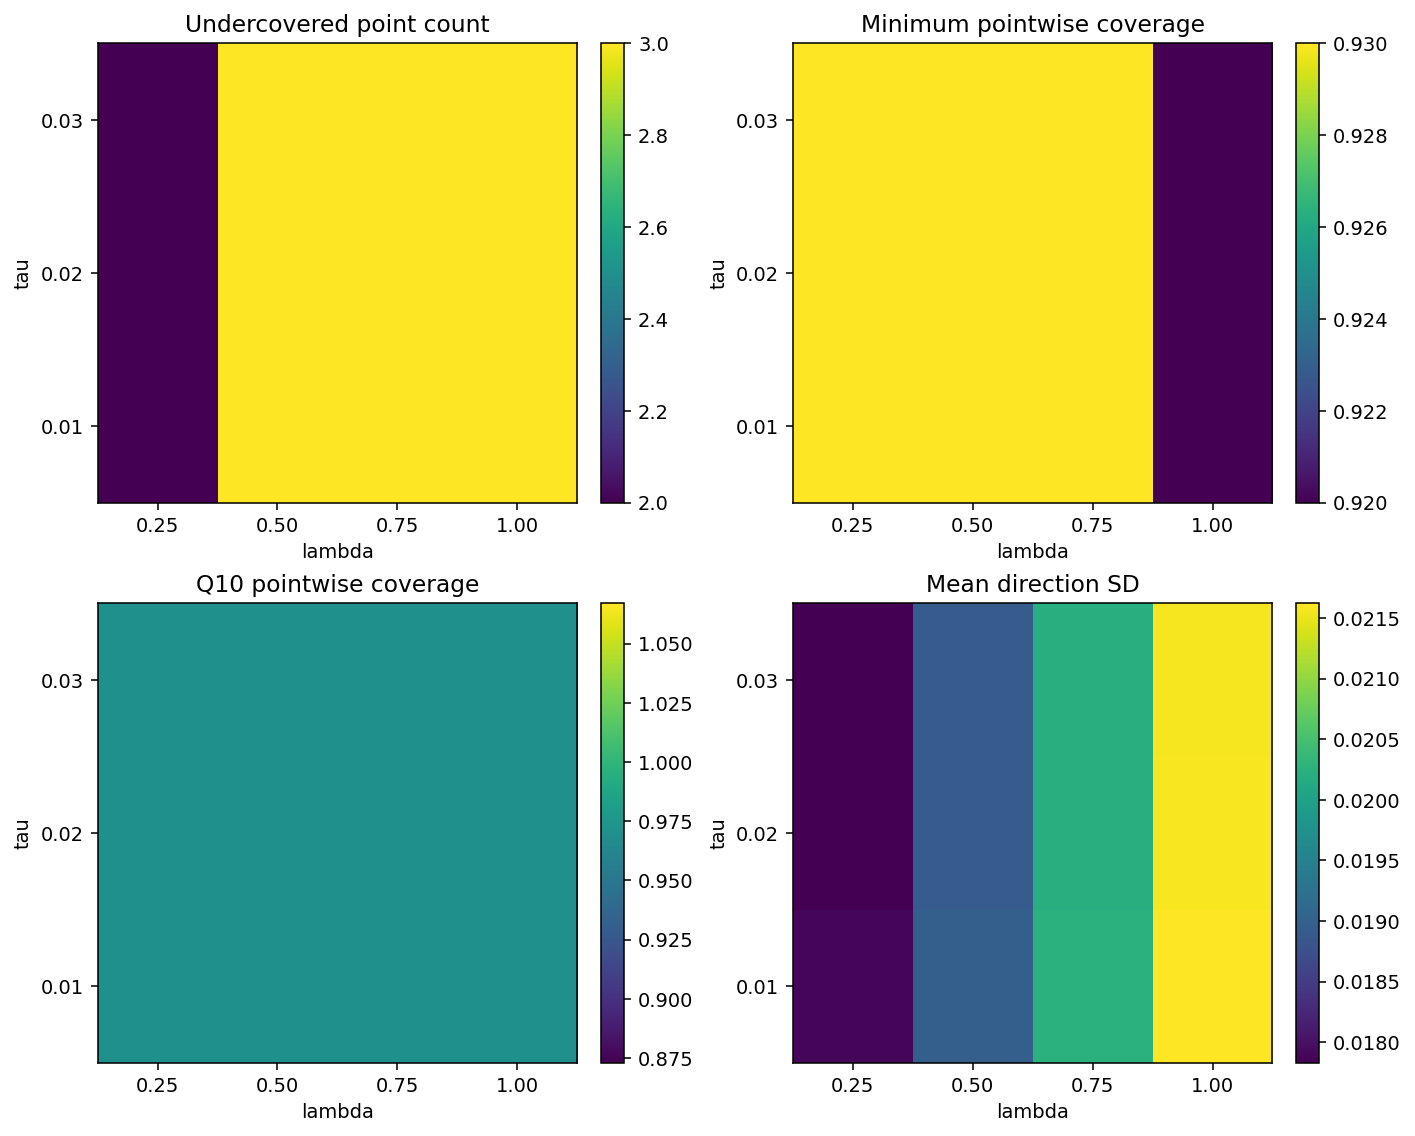

In [7]:
pivot_under = fine_overall.pivot(index="tau", columns="lambda", values="offline_undercovered_points")
pivot_min = fine_overall.pivot(index="tau", columns="lambda", values="offline_min_pointwise_coverage")
pivot_q10 = fine_overall.pivot(index="tau", columns="lambda", values="offline_q10_pointwise_coverage")
pivot_dir = fine_overall.pivot(index="tau", columns="lambda", values="mean_dir_sd")

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

ims = []
for ax, mat, title in [
    (axes[0,0], pivot_under, "Undercovered point count"),
    (axes[0,1], pivot_min, "Minimum pointwise coverage"),
    (axes[1,0], pivot_q10, "Q10 pointwise coverage"),
    (axes[1,1], pivot_dir, "Mean direction SD"),
]:
    im = ax.imshow(mat.values, aspect="auto", origin="lower")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(mat.columns)))
    ax.set_xticklabels([f"{c:.2f}" for c in mat.columns])
    ax.set_yticks(np.arange(len(mat.index)))
    ax.set_yticklabels([f"{r:.2f}" for r in mat.index])
    ax.set_xlabel("lambda")
    ax.set_ylabel("tau")
    fig.colorbar(im, ax=ax)
    ims.append(im)

plt.savefig(OUT_DIR / "02_fine_grid_heatmaps.png", bbox_inches="tight")
plt.show()


## 7. Compare the top few candidates

In [8]:
top_k = 4
top_candidates = ranking_df.head(top_k).copy()
top_candidates


,lambda,tau,offline_undercovered_points,offline_min_pointwise_coverage,offline_q10_pointwise_coverage,offline_mean_pointwise_coverage,mean_dir_sd,mean_g_pseudo,mean_alpha_star
0,0.25,0.03,2,0.93,0.97,0.9930,0.017831,0.012543,0.85792
1,0.25,0.02,2,0.93,0.97,0.9930,0.017841,0.012551,0.85796
2,0.25,0.01,2,0.93,0.97,0.9930,0.017877,0.012578,0.85804
3,0.50,0.03,3,0.93,0.97,0.9926,0.018928,0.013604,0.87078


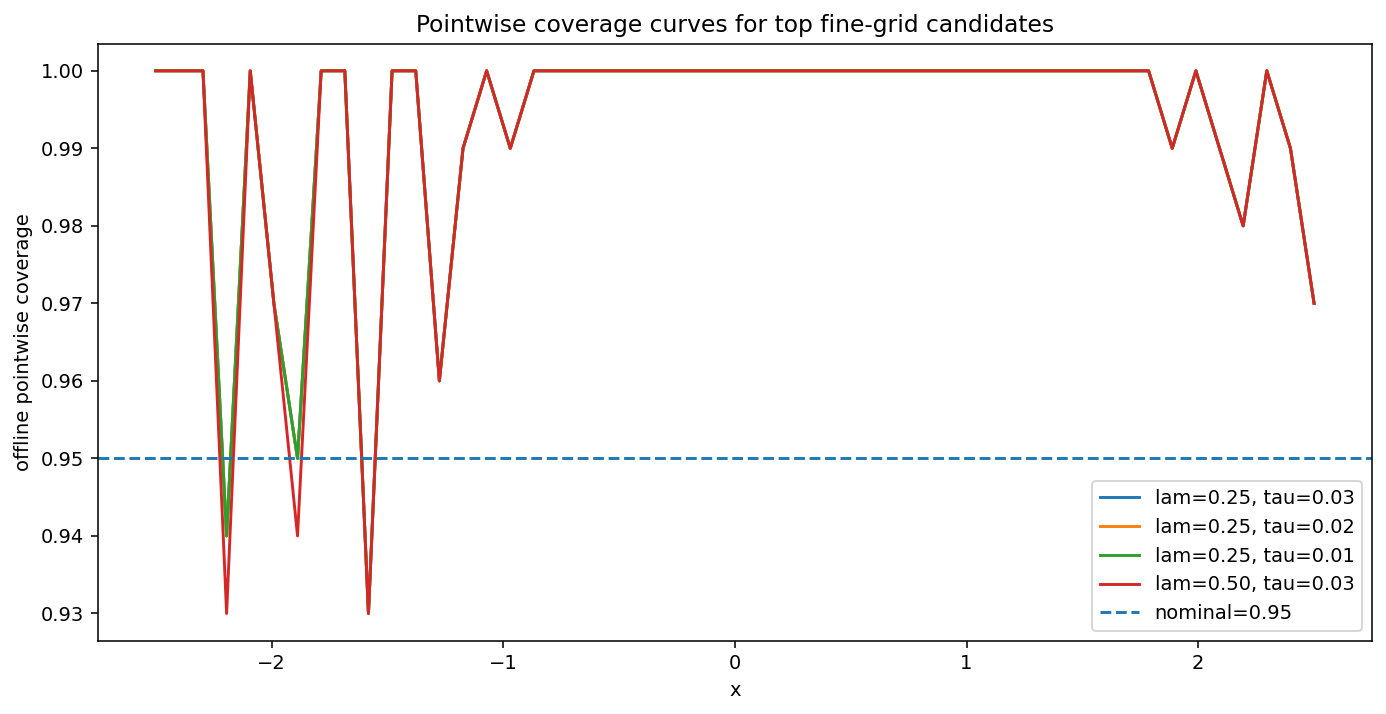

In [9]:
if "offline_pointwise_coverage" in fine_pointwise.columns:
    plt.figure(figsize=(10, 5.2))
    for _, row in top_candidates.iterrows():
        lam = row["lambda"]
        tau = row["tau"]
        df = fine_pointwise[(fine_pointwise["lambda"] == lam) & (fine_pointwise["tau"] == tau)].sort_values("x")
        label = f"lam={lam:.2f}, tau={tau:.2f}"
        plt.plot(df["x"], df["offline_pointwise_coverage"], label=label)
    plt.axhline(NOMINAL, linestyle="--", label=f"nominal={NOMINAL:.2f}")
    plt.xlabel("x")
    plt.ylabel("offline pointwise coverage")
    plt.title("Pointwise coverage curves for top fine-grid candidates")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_top_candidates_pointwise_curves.png", bbox_inches="tight")
    plt.show()


## 8. Remaining failure points for the best candidate

In [10]:
best = ranking_df.iloc[0]
best_lam = float(best["lambda"])
best_tau = float(best["tau"])

best_df = fine_pointwise[(fine_pointwise["lambda"] == best_lam) & (fine_pointwise["tau"] == best_tau)].sort_values("x").reset_index(drop=True)
best_df.head()


,x,alpha_star_mean,alpha_star_sd,g_pseudo_mean,dir_sd_mean,width_ratio_mean,center_shift_mean,scale_shift_mean,offline_pointwise_coverage,lambda,tau
0,-2.500000,0.239,0.125445,0.02149,0.061399,0.653593,0.509738,-0.425555,1.00,0.25,0.03
1,-2.397959,0.806,0.283848,0.02174,0.038116,0.640845,0.205885,-0.445479,1.00,0.25,0.03
2,-2.295918,0.586,0.248234,0.02347,0.026754,0.691238,0.393539,-0.369359,1.00,0.25,0.03
3,-2.193878,0.418,0.171964,0.02378,0.032579,0.683212,0.314722,-0.381002,0.94,0.25,0.03
4,-2.091837,0.924,0.184840,0.01679,0.024266,0.689972,0.105170,-0.371163,1.00,0.25,0.03


In [11]:
if "offline_pointwise_coverage" in best_df.columns:
    remain_fail = best_df.loc[best_df["offline_pointwise_coverage"] < NOMINAL].copy()
    remain_fail = remain_fail.sort_values(["offline_pointwise_coverage", "x"], ascending=[True, True]).reset_index(drop=True)
    remain_fail.to_csv(OUT_DIR / "04_remaining_fail_points_best_candidate.csv", index=False)
    remain_fail
else:
    print("No offline_pointwise_coverage column available.")


## 9. Diagnostic profile of the best candidate

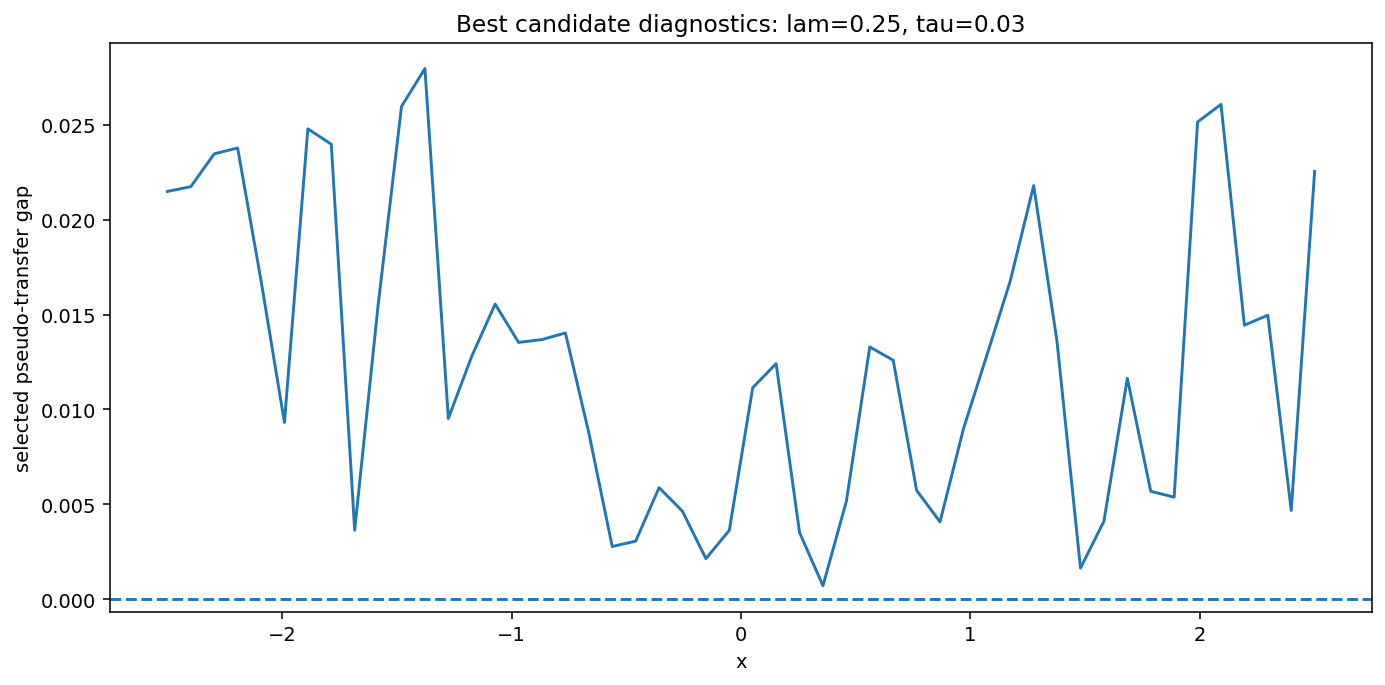

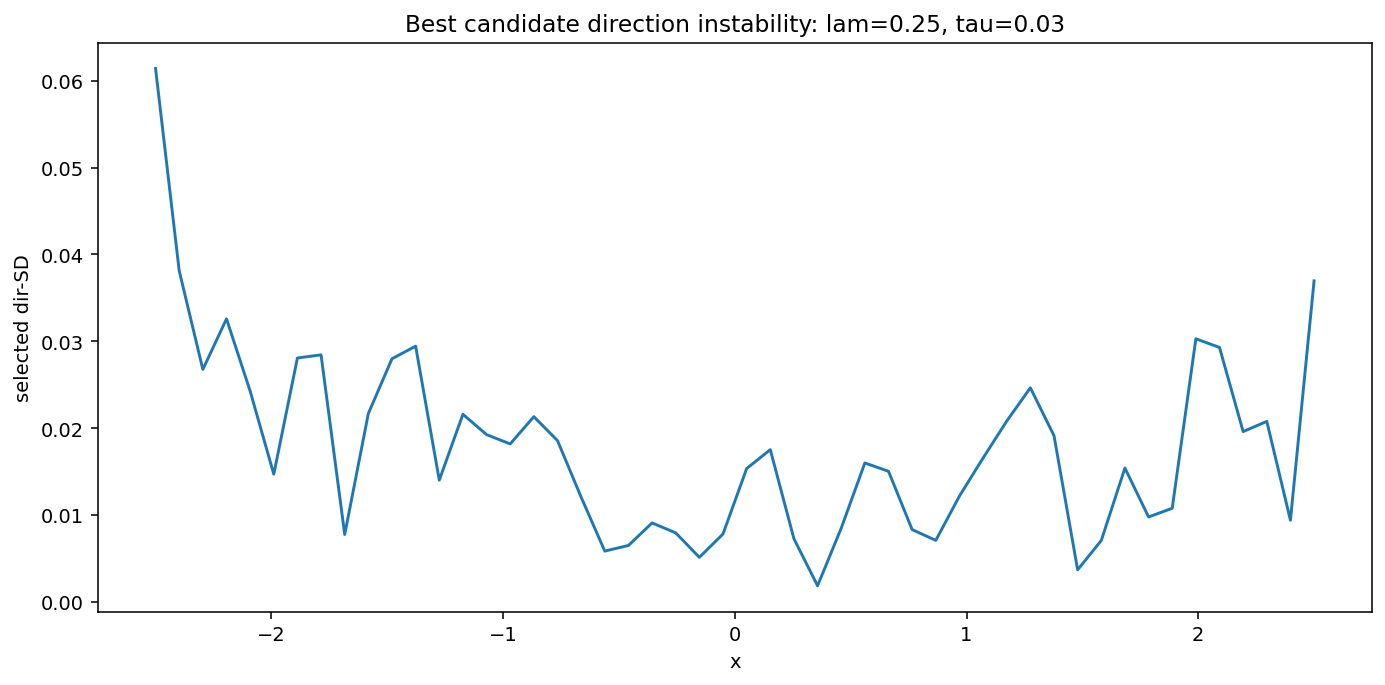

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(best_df["x"], best_df["g_pseudo_mean"], label="g_pseudo_mean")
plt.axhline(0.0, linestyle="--")
plt.xlabel("x")
plt.ylabel("selected pseudo-transfer gap")
plt.title(f"Best candidate diagnostics: lam={best_lam:.2f}, tau={best_tau:.2f}")
plt.tight_layout()
plt.savefig(OUT_DIR / "05_best_candidate_pseudo_gap.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(best_df["x"], best_df["dir_sd_mean"], label="dir_sd_mean")
plt.xlabel("x")
plt.ylabel("selected dir-SD")
plt.title(f"Best candidate direction instability: lam={best_lam:.2f}, tau={best_tau:.2f}")
plt.tight_layout()
plt.savefig(OUT_DIR / "06_best_candidate_dir_sd.png", bbox_inches="tight")
plt.show()


## 10. Compare against the previously best local result

In [13]:
prev_offline_path = PREV_LCB_ROOT / "offline_compare.csv"
if prev_offline_path.exists():
    prev_offline = pd.read_csv(prev_offline_path)
    prev_best = prev_offline.sort_values(
        by=[
            "offline_undercovered_points_nominal_095",
            "offline_min_pointwise_coverage",
            "offline_q10_pointwise_coverage",
        ],
        ascending=[True, False, False]
    ).reset_index(drop=True).iloc[0]

    compare_prev_vs_new = pd.DataFrame([
        {
            "source": "previous_best",
            "strategy_or_grid": str(prev_best["strategy"]),
            "undercovered": float(prev_best["offline_undercovered_points_nominal_095"]),
            "min_pointwise": float(prev_best["offline_min_pointwise_coverage"]),
            "q10_pointwise": float(prev_best["offline_q10_pointwise_coverage"]),
            "mean_dir_sd": float(prev_best["mean_dir_sd"]),
        },
        {
            "source": "new_fine_grid_best",
            "strategy_or_grid": f"lam={best_lam:.2f}, tau={best_tau:.2f}",
            "undercovered": float(best["offline_undercovered_points"]),
            "min_pointwise": float(best["offline_min_pointwise_coverage"]),
            "q10_pointwise": float(best["offline_q10_pointwise_coverage"]),
            "mean_dir_sd": float(best["mean_dir_sd"]),
        },
    ])
    compare_prev_vs_new.to_csv(OUT_DIR / "07_compare_prev_vs_new_best.csv", index=False)
    compare_prev_vs_new
else:
    print("No previous offline_compare.csv found.")


## 11. Quick recommendation

In [14]:
print("Best fine-grid candidate:")
print(f"  lambda = {best_lam:.2f}")
print(f"  tau    = {best_tau:.2f}")
print(f"  undercovered points = {int(best['offline_undercovered_points'])}")
print(f"  min pointwise coverage = {float(best['offline_min_pointwise_coverage']):.4f}")
print(f"  q10 pointwise coverage = {float(best['offline_q10_pointwise_coverage']):.4f}")
print(f"  mean dir-SD = {float(best['mean_dir_sd']):.6f}")
print(f"  mean g_pseudo = {float(best['mean_g_pseudo']):.6f}")
print()
print("Saved files:")
for p in sorted(OUT_DIR.iterdir()):
    print(" ", p.name)


Best fine-grid candidate:
  lambda = 0.25
  tau    = 0.03
  undercovered points = 2
  min pointwise coverage = 0.9300
  q10 pointwise coverage = 0.9700
  mean dir-SD = 0.017831
  mean g_pseudo = 0.012543

Saved files:
  01_fine_grid_ranking.csv
  02_fine_grid_heatmaps.png
  03_top_candidates_pointwise_curves.png
  04_remaining_fail_points_best_candidate.csv
  05_best_candidate_pseudo_gap.png
  06_best_candidate_dir_sd.png
  07_compare_prev_vs_new_best.csv
  fine_overall_compare.csv
  fine_pointwise_compare.csv
